In [1]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Config ──────────────────────────────────────────────
CFG = {
    'data_dir'   : r'D:\ScanO-assign-Apaar\dataset',
    'img_size'   : 224,
    'batch_size' : 32,
    'epochs'     : 15,
    'lr'         : 1e-3,
    'seed'       : 42,
    'save_path'  : 'outputs/best_model.pth',
    'device'     : 'cpu',
}

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
os.makedirs('outputs/sample_outputs', exist_ok=True)
print('Config:', json.dumps(CFG, indent=2))

Config: {
  "data_dir": "D:\\ScanO-assign-Apaar\\dataset",
  "img_size": 224,
  "batch_size": 32,
  "epochs": 15,
  "lr": 0.001,
  "seed": 42,
  "save_path": "outputs/best_model.pth",
  "device": "cpu"
}


In [2]:
# ── Transforms ──────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # X-rays are grayscale → replicate to 3ch
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3),
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3),
])

# ── Datasets ────────────────────────────────────────────
train_dataset = datasets.ImageFolder(os.path.join(CFG['data_dir'], 'train'), transform=train_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(CFG['data_dir'], 'test'),  transform=val_transforms)

CLASS_NAMES = train_dataset.classes   # ['normal', 'pneumonia']
print('Classes:', CLASS_NAMES)
print(f'Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}')

# ── Class distribution ──────────────────────────────────
targets = np.array(train_dataset.targets)
class_counts = np.bincount(targets)
print(f'Train — Normal: {class_counts[0]} | Pneumonia: {class_counts[1]}')

Classes: ['normal', 'pneumonia']
Train samples: 640 | Test samples: 160
Train — Normal: 314 | Pneumonia: 326


In [3]:
# ── WeightedRandomSampler (handle imbalance) ────────────
class_weights = 1.0 / class_counts
sample_weights = class_weights[targets]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], sampler=sampler,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 20 | Test batches: 5


In [4]:
class ConvBlock(nn.Module):
    """Conv → BN → ReLU → MaxPool"""
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ChestCNN(nn.Module):
    """
    4-block custom CNN.
    Input : (B, 3, 224, 224)
    Output: (B, 2)

    Architecture note for Grad-CAM:
    - self.features outputs spatial feature maps (B, 256, 14, 14)
    - self.gap collapses spatial dims AFTER features
    - Grad-CAM hooks self.features directly to capture (B,256,14,14)
      BEFORE GAP destroys spatial information.
    """
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        self.block1 = ConvBlock(3,   32)   # → 112×112
        self.block2 = ConvBlock(32,  64)   # →  56×56
        self.block3 = ConvBlock(64, 128)   # →  28×28
        self.block4 = ConvBlock(128, 256)  # →  14×14  ← Grad-CAM hooks HERE
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)   # spatial feature maps preserved here
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.classifier(x)


model = ChestCNN(num_classes=2)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
print(model)

Trainable parameters: 389,410
ChestCNN(
  (block1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block3): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            if training:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
start = time.time()

for epoch in range(1, CFG['epochs'] + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(test_loader,  training=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CFG['save_path'])

    elapsed = (time.time() - start) / 60
    print(f'Epoch {epoch:02d}/{CFG["epochs"]} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | '
          f'Time: {elapsed:.1f}m')

print(f'\nBest Val Acc: {best_val_acc:.4f}')
print(f'Total training time: {(time.time()-start)/60:.1f} min')

Epoch 01/15 | Train Loss: 0.5706 Acc: 0.7125 | Val Loss: 1.2802 Acc: 0.5000 | Time: 1.4m
Epoch 02/15 | Train Loss: 0.4700 Acc: 0.8109 | Val Loss: 0.4378 Acc: 0.8063 | Time: 2.5m
Epoch 03/15 | Train Loss: 0.4809 Acc: 0.8156 | Val Loss: 0.4654 Acc: 0.7937 | Time: 3.6m
Epoch 04/15 | Train Loss: 0.4372 Acc: 0.8203 | Val Loss: 0.3808 Acc: 0.8625 | Time: 4.7m
Epoch 05/15 | Train Loss: 0.4094 Acc: 0.8359 | Val Loss: 0.3219 Acc: 0.8875 | Time: 5.8m
Epoch 06/15 | Train Loss: 0.3778 Acc: 0.8672 | Val Loss: 0.3232 Acc: 0.8750 | Time: 7.0m
Epoch 07/15 | Train Loss: 0.4146 Acc: 0.8453 | Val Loss: 0.3195 Acc: 0.8875 | Time: 8.4m
Epoch 08/15 | Train Loss: 0.3847 Acc: 0.8547 | Val Loss: 0.3984 Acc: 0.8063 | Time: 9.6m
Epoch 09/15 | Train Loss: 0.3749 Acc: 0.8516 | Val Loss: 0.3809 Acc: 0.8000 | Time: 10.8m
Epoch 10/15 | Train Loss: 0.3972 Acc: 0.8375 | Val Loss: 0.5229 Acc: 0.8000 | Time: 12.0m
Epoch 11/15 | Train Loss: 0.3825 Acc: 0.8578 | Val Loss: 0.3167 Acc: 0.8500 | Time: 13.1m
Epoch 12/15 | Trai

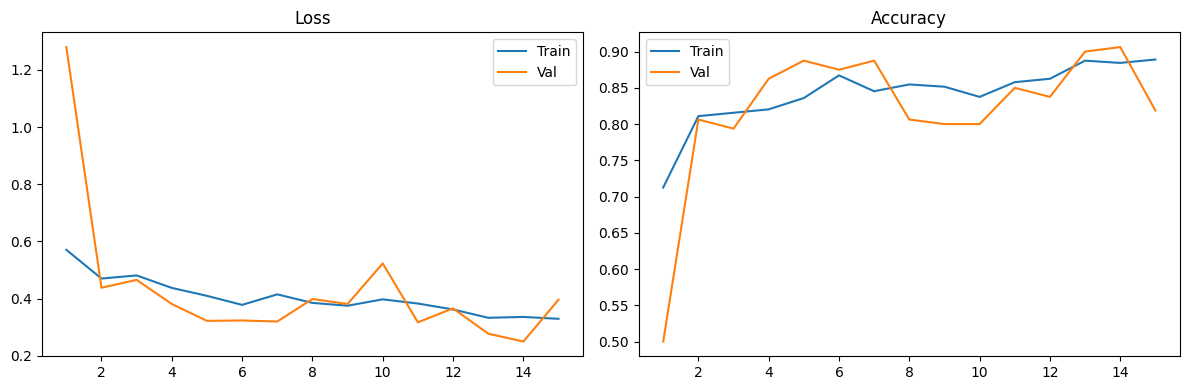

Saved → outputs/sample_outputs/training_curves.png


In [6]:
epochs_range = range(1, CFG['epochs'] + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/sample_outputs/training_curves.png', dpi=150)
plt.show()
print('Saved → outputs/sample_outputs/training_curves.png')

In [7]:
import cv2
from PIL import Image

class GradCAM:
    """
    Previous bug: hooking inside nn.Sequential lost spatial gradients because GAP collapsed them to 1x1 before backward reached the hook.
    Solution: Hook the entire block4 module output — this captures the full (B,256,14,14) spatial feature map that Grad-CAM needs.
    Fix: Hook model.block4 (output shape: B,256,14,14) BEFORE GAP.
    """
    def __init__(self, model):
        self.model       = model
        self.activations = None
        self.gradients   = None
        # Hook block4 output — spatial maps (B, 256, 14, 14)
        model.block4.register_forward_hook(self._save_activation)
        model.block4.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, _, __, output):
        self.activations = output.detach()           # (B, 256, 14, 14)

    def _save_gradient(self, _, __, grad_output):
        self.gradients = grad_output[0].detach()     # (B, 256, 14, 14)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        # Need grad flow → do NOT use torch.no_grad()
        input_tensor = input_tensor.requires_grad_(True)
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # α_k = global average of gradients over spatial dims
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, 256, 1, 1)
        # Weighted combination of activation maps
        cam = (weights * self.activations).sum(dim=1).squeeze()  # (14, 14)
        cam = torch.relu(cam).numpy()

        # Normalise to [0, 1] — guard against all-zero cam
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)

        return cam, class_idx


def overlay_gradcam(img_path, cam, save_path, img_size=224):
    """Overlay Grad-CAM heatmap on the original X-ray and save."""
    orig = np.array(Image.open(img_path).convert('RGB').resize((img_size, img_size)))

    # Upsample 14×14 CAM → 224×224
    cam_resized = cv2.resize(cam, (img_size, img_size))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay     = np.uint8(0.5 * orig + 0.5 * heatmap)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(orig);           axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(cam_resized,
                   cmap='jet',
                   vmin=0, vmax=1);  axes[1].set_title('Grad-CAM');  axes[1].axis('off')
    axes[2].imshow(overlay);        axes[2].set_title('Overlay');   axes[2].axis('off')
    plt.colorbar(plt.cm.ScalarMappable(cmap='jet'), ax=axes[1], fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()


# Attach to block4 — correct hook point
gradcam = GradCAM(model)
print('GradCAM ready — hooked to model.block4 (B,256,14,14)')

GradCAM ready — hooked to model.block4 (B,256,14,14)


In [8]:
# ── Generate Grad-CAM for 4 sample images (2 per class) ─
model.load_state_dict(torch.load(CFG['save_path'], map_location='cpu'))
gradcam = GradCAM(model)   # re-attach hooks after reload

sample_paths = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(CFG['data_dir'], 'test', cls)
    imgs    = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    sample_paths += [(os.path.join(cls_dir, imgs[i]), cls) for i in range(min(2, len(imgs)))]

for img_path, true_cls in sample_paths:
    img_tensor = val_transforms(Image.open(img_path).convert('RGB')).unsqueeze(0)
    cam, pred_idx = gradcam.generate(img_tensor)
    pred_cls      = CLASS_NAMES[pred_idx]
    fname         = f'gradcam_{true_cls}_pred{pred_cls}_{os.path.basename(img_path)}'
    save_path     = os.path.join('outputs/sample_outputs', fname)
    overlay_gradcam(img_path, cam, save_path)
    print(f'Saved: {save_path}  (true={true_cls}, pred={pred_cls})')

Saved: outputs/sample_outputs\gradcam_normal_prednormal_IM-0115-0001.jpeg  (true=normal, pred=normal)
Saved: outputs/sample_outputs\gradcam_normal_prednormal_IM-0177-0001.jpeg  (true=normal, pred=normal)
Saved: outputs/sample_outputs\gradcam_pneumonia_predpneumonia_person1031_bacteria_2963.jpeg  (true=pneumonia, pred=pneumonia)
Saved: outputs/sample_outputs\gradcam_pneumonia_predpneumonia_person1134_bacteria_3076.jpeg  (true=pneumonia, pred=pneumonia)
